In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv("../data/processed/jogadores_saque.csv")

df.head()

,tourney_id,tourney_date,surface,tourney_level,best_of,round,player_id,player_name,hand,ht,...,df,svpt,firstIn,firstWon,secondWon,SvGms,venceu_partida,pct_pontos_saque_ganhos,pct_primeiro_saque_dentro,aces_por_100_saques
0,2010-339,20100103,Hard,250,3,R32,R485,Andy Roddick,R,188.0,...,0.0,63.0,42.0,36.0,14.0,10.0,1,79.365079,66.666667,23.809524
1,2010-339,20100103,Hard,250,3,R32,BD59,Carsten Ball,L,198.0,...,3.0,57.0,30.0,23.0,19.0,10.0,1,73.684211,52.631579,17.543860
2,2010-339,20100103,Hard,250,3,R32,G628,Richard Gasquet,R,183.0,...,4.0,97.0,51.0,33.0,27.0,15.0,1,61.855670,52.577320,5.154639
3,2010-339,20100103,Hard,250,3,R32,E690,Matthew Ebden,R,188.0,...,1.0,50.0,35.0,30.0,12.0,10.0,1,84.000000,70.000000,24.000000
4,2010-339,20100103,Hard,250,3,R32,BA47,Tomas Berdych,R,196.0,...,1.0,46.0,27.0,24.0,14.0,9.0,1,82.608696,58.695652,6.521739


In [2]:
df_treino, df_teste = train_test_split(df, test_size=0.2, random_state=42)

print("Tamanho do Treino:", df_treino.shape)
print("Tamanho do Teste:", df_teste.shape)

Tamanho do Treino: (61128, 23)
Tamanho do Teste: (15282, 23)


In [3]:
minha_f = 'pct_pontos_saque_ganhos ~ ht + age + surface + np.log(rank)'
modelo = smf.ols(formula=minha_f, data=df_treino)
modelo_treinado = modelo.fit()
modelo_treinado.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     pct_pontos_saque_ganhos   R-squared:                       0.112
Model:                                 OLS   Adj. R-squared:                  0.112
Method:                      Least Squares   F-statistic:                     1539.
Date:                     Sun, 04 Oct 2026   Prob (F-statistic):               0.00
Time:                             19:30:58   Log-Likelihood:            -2.1631e+05
No. Observations:                    60933   AIC:                         4.326e+05
Df Residuals:                        60927   BIC:                         4.327e+05
Df Model:                                5                                         
Covariance Type:                 nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           29.4620      0.982     29.997      0.000      27.537      31.387
surface[T.Grass]     3.9397      0.118     33.312      0.000       3.708       4.171
surface[T.Hard]      1.8241      0.076     23.890      0.000       1.674       1.974
ht                   0.2077      0.005     42.831      0.000       0.198       0.217
age                  0.0174      0.008      2.097      0.036       0.001       0.034
np.log(rank)        -1.7650      0.030    -58.252      0.000      -1.824      -1.706
==============================================================================
Omnibus:                      479.488   Durbin-Watson:                   2.005
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              566.069
Skew:                          -0.158   Prob(JB):                    1.20e-123
Kurtosis:                       3.350   Cond. No.                     5.44e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.44e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [6]:
colunas_modelo = ['pct_pontos_saque_ganhos', 'ht', 'age', 'surface', 'rank']
df_teste_limpo = df_teste.dropna(subset=colunas_modelo)

previsoes = modelo_treinado.predict(df_teste_limpo)

erro_medio = mean_absolute_error(df_teste_limpo['pct_pontos_saque_ganhos'], previsoes)
r2_teste = r2_score(df_teste_limpo['pct_pontos_saque_ganhos'], previsoes)
residuos = df_teste_limpo['pct_pontos_saque_ganhos'] - previsoes

print(f"Erro médio absoluto: {erro_medio:.2f}")
print(f"R2 teste: {r2_teste:.2f}")
print(f"O quanto o modelo errou em cada partida de teste: {residuos}")

Erro médio absoluto: 6.70
R2 teste: 0.10
O quanto o modelo errou em cada partida de teste: 41572    -8.534781
43896   -12.419283
37552    -2.220787
67939     6.817278
67813    -1.516291
           ...    
18093     5.465922
25137     7.620852
11542     4.292180
23842     0.072774
11940     3.793388
Length: 15232, dtype: float64


Text(0, 0.5, 'Frequência')

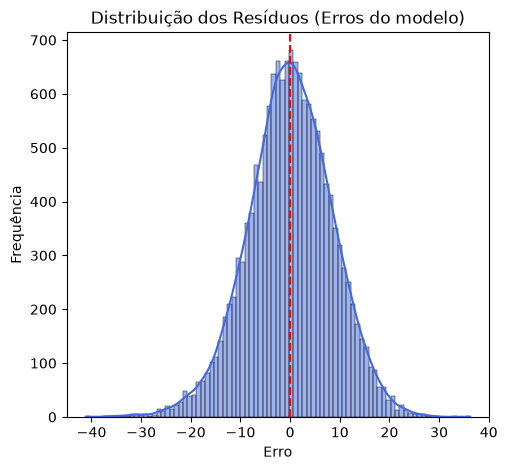

In [9]:
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
sns.histplot(residuos, kde=True, color='royalblue')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribuição dos Resíduos (Erros do modelo)')
plt.xlabel('Erro')
plt.ylabel('Frequência')

Text(0, 0.5, 'Valor Real')

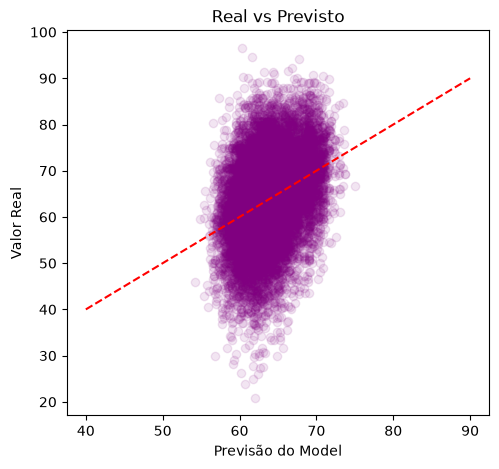

In [11]:
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 2)
plt.scatter(previsoes, df_teste_limpo['pct_pontos_saque_ganhos'], alpha=0.1, color='purple')
plt.plot([40, 90], [40, 90], color='red', linestyle='--')
plt.title('Real vs Previsto')
plt.xlabel('Previsão do Model')
plt.ylabel('Valor Real')